In [20]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score



In [3]:
def read_cv_file(filepath):
    df = pd.read_excel(filepath, sheet_name=0, header=None)

    #Ambil kolom ke 19 yaitu µA dari Scan ke 10, karena merupakan data Scan paling terakhir dan biasanya paling stabil kondisinya
    #Fitur V tidak diambil karena di semua data nilainya sama, sehingga tidak memengaruhi perubahan Y
    scan10_uA = df.iloc[2:, 19]
    scan10_uA = pd.to_numeric(scan10_uA, errors='coerce').dropna().values
    return scan10_uA

def load_all_data(root_folder):
    X_list = []
    y_list = []
    meta_list = []
    for subfolder in os.listdir(root_folder):
        subfolder_path = os.path.join(root_folder, subfolder)
        
        if not os.path.isdir(subfolder_path):
            continue
        
        #Y
        if subfolder.upper() == 'KCL':
            concentration = 0
        else:
            try:
                concentration = int(subfolder)
            except ValueError:
                print(f"Skip folder tidak dikenal: {subfolder}")
                continue
        
        #Baca file
        for filename in os.listdir(subfolder_path):
            if not filename.endswith('.xlsx'):
                continue
            
            filepath = os.path.join(subfolder_path, filename)
            
            try:
                features = read_cv_file(filepath)
                
                X_list.append(features)
                y_list.append(concentration)
                meta_list.append({'file': filename, 'folder': subfolder})
                
            except Exception as e:
                print(f"Error membaca {filename}: {e}")
    
    lengths = [len(x) for x in X_list]
    min_len = min(lengths)
    print(f"Panjang fitur: min={min_len}, max={max(lengths)}")
    
    # Trim ke panjang minimum jika ada perbedaan
    X_array = np.array([x[:min_len] for x in X_list])
    y_array = np.array(y_list)
    
    return X_array, y_array, meta_list

In [5]:
root_folder = "D:\KULIAH\S4\Latihan\Alat Sensor CD Groundturth"

X, y, meta = load_all_data(root_folder)

print(f"   X shape : {X.shape}  → (jumlah_sampel, jumlah_fitur)")
print(f"   y shape : {y.shape}  → (jumlah_sampel,)")
print(f"   Kelas Y : {sorted(set(y.tolist()))}")

# Buat nama kolom untuk setiap fitur µA
voltage_labels = [f"uA_V{i+1}" for i in range(X.shape[1])]

# Gabung X Y
df_final = pd.DataFrame(X, columns=voltage_labels)
df_final['konsentrasi_ppm'] = y

# Export ke CSV
df_final.to_csv('dataset_cadmium.csv', index=False)
print(df_final.head())

Panjang fitur: min=181, max=181
   X shape : (797, 181)  → (jumlah_sampel, jumlah_fitur)
   y shape : (797,)  → (jumlah_sampel,)
   Kelas Y : [0, 2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000]
       uA_V1      uA_V2      uA_V3      uA_V4      uA_V5      uA_V6  \
0  23.530174  20.541814  18.208244  16.334059  14.671248  13.266784   
1  24.228178  21.297124  19.023678  17.144794  15.538351  14.138585   
2  24.566378  21.588350  19.314904  17.407840  15.792000  14.373445   
3  24.885788  21.870184  19.568552  17.652092  16.026861  14.580122   
4  25.054888  22.029888  19.709470  17.783614  16.148988  14.683461   

       uA_V7      uA_V8      uA_V9     uA_V10  ...    uA_V173    uA_V174  \
0  11.943112  10.799812   9.677181   8.703920  ...  20.938258  21.150572   
1  12.879734  11.743011  10.690837   9.742002  ...  22.058072  22.067466   
2  13.095805  11.940293  10.897514   9.939284  ...  22.396270  22.377482   
3  13.311877  12.137576  11.094796  10.108384  ...  22.69689

In [6]:
#X = [µA_v1, µA_v2, ..., µA_v181] -> 181 kolom (dari Scan 10)
#Y = konsentrasi (ppm) -> diambil dari nama folder
X = df_final.drop(columns=['konsentrasi_ppm'])
y = df_final['konsentrasi_ppm']

# Split 80:20, stratify agar tiap konsentrasi terwakili proporsional
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

X_train : (637, 181)
X_test  : (160, 181)
y_train : (637,)
y_test  : (160,)


In [11]:
#Standar Scaler
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)  # fit hanya di train
X_test_sc  = scaler.transform(X_test)       # test hanya transform

In [17]:
#Model RF
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [18]:
#Encoder untuk model XGBoost
# le = LabelEncoder()

# y_train_enc = le.fit_transform(y_train)
# y_test_enc  = le.transform(y_test)

#Model XGBoost
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [21]:
# MAE (semakin kecil semakin bagus)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# RMSE (lebih sensitif terhadap error besar)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

# R2
r2_rf = r2_score(y_test, y_pred_rf)
r2_xgb = r2_score(y_test, y_pred_xgb)


print("=== Random Forest ===")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 Score:", r2_rf)

print("\n=== XGBoost ===")
print("MAE  :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R2 Score:", r2_xgb)

=== Random Forest ===
MAE  : 15.206062500000002
RMSE : 56.62303543501532
R2 Score: 0.9664531085895804

=== XGBoost ===
MAE  : 11.9003324508667
RMSE : 54.39190873951865
R2 Score: 0.9690447449684143


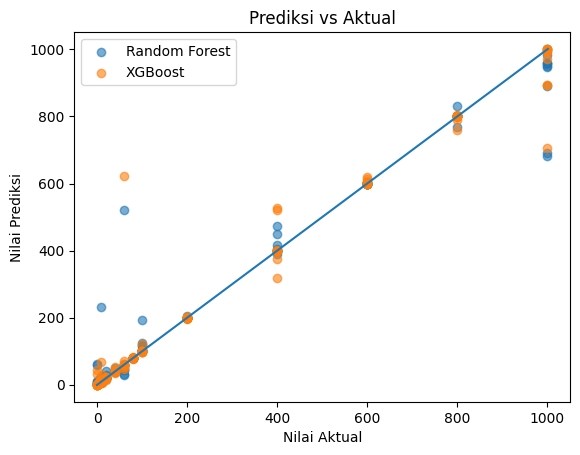

In [23]:
plt.figure()

plt.scatter(y_test, y_pred_rf, alpha=0.6, label="Random Forest")
plt.scatter(y_test, y_pred_xgb, alpha=0.6, label="XGBoost")

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Nilai Aktual")
plt.ylabel("Nilai Prediksi")
plt.title("Prediksi vs Aktual")
plt.legend()

plt.show()

In [14]:
print("Accuracy RF  :", accuracy_score(y_test, y_pred_rf))
print("Accuracy XGB :", accuracy_score(y_test, y_pred_xgb))

Accuracy RF  : 0.98125
Accuracy XGB : 0.9625
